# Session 06 - Supervised Learning and Regression

Build a regression model and interpret errors in business terms. This notebook uses a synthetic UK workplace salary dataset for classroom practice only.

## 1. Setup
Import Pandas and Scikit-learn tools for a fair baseline-vs-linear-regression comparison.

In [54]:
from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', 50)

## 2. Load and inspect the dataset

In [55]:
DATA_PATH = Path('workplace_salary_regression_dataset.csv')
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
df.head()

Shape: (720, 15)


,employee_record_id,region,role_family,sector,company_size,education_level,seniority_level,years_experience,professional_certifications,technical_skill_score,remote_days_per_week,people_management,weekly_contract_hours,training_hours_last_12m,annual_salary_gbp
0,EMP-0187,North West,Operations,Retail,Medium,Professional certification,Associate,1.9,1,54.2,0,0,34.2,17.3,56000
1,EMP-0497,North West,Software,Education,Large,Professional certification,Associate,3.7,2,93.6,4,0,37.9,66.2,84900
2,EMP-0321,South West,Data,Technology,Medium,Master,Senior,2.1,2,81.5,1,0,40.2,32.0,92900
3,EMP-0363,London,People,Technology,Medium,Bachelor,Mid,6.6,2,77.3,2,0,42.4,61.3,88300
4,EMP-0610,North West,Data,Retail,Enterprise,Professional certification,Associate,8.2,3,77.3,2,0,36.4,44.6,93600


In [56]:
df.info()
df['annual_salary_gbp'].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   employee_record_id           720 non-null    object 
 1   region                       720 non-null    object 
 2   role_family                  720 non-null    object 
 3   sector                       720 non-null    object 
 4   company_size                 720 non-null    object 
 5   education_level              720 non-null    object 
 6   seniority_level              720 non-null    object 
 7   years_experience             720 non-null    float64
 8   professional_certifications  720 non-null    int64  
 9   technical_skill_score        720 non-null    float64
 10  remote_days_per_week         720 non-null    int64  
 11  people_management            720 non-null    int64  
 12  weekly_contract_hours        720 non-null    float64
 13  training_hours_last_

,annual_salary_gbp
count,720.000000
mean,84741.388889
std,14055.526020
min,47600.000000
25%,74475.000000
50%,83600.000000
75%,93625.000000
max,127500.000000


## 3. Define target and features
The target is `annual_salary_gbp`. We remove the record ID because it is not a real predictive signal.

In [57]:
target = 'annual_salary_gbp'
id_col = 'employee_record_id'
X = df.drop(columns=[target, id_col])
y = df[target]

print('Feature columns:', list(X.columns))
print('Target:', target)

Feature columns: ['region', 'role_family', 'sector', 'company_size', 'education_level', 'seniority_level', 'years_experience', 'professional_certifications', 'technical_skill_score', 'remote_days_per_week', 'people_management', 'weekly_contract_hours', 'training_hours_last_12m']
Target: annual_salary_gbp


## 4. Train/test split
The test set must remain unseen until evaluation. This protects the credibility of model performance.

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print('Training rows:', X_train.shape[0])
print('Test rows:', X_test.shape[0])

Training rows: 576
Test rows: 144


## 5. Build a baseline predictor
A baseline predictor gives us a simple reference. Here it predicts the mean salary from the training data.

In [59]:
baseline = DummyRegressor(strategy='mean')
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

## 6. Build a linear regression pipeline
Numeric features are scaled. Categorical features are one-hot encoded. The transformations are fitted as part of the pipeline.

In [60]:
numeric_features = X.select_dtypes(include=['number']).columns.tolist()
categorical_features = X.select_dtypes(exclude=['number']).columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ]
)

linear_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', LinearRegression())
])

linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)

## 7. Evaluate MAE, RMSE, and R2

In [61]:
def regression_report(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {'model': model_name, 'MAE_GBP': mae, 'RMSE_GBP': rmse, 'R2': r2}

results = pd.DataFrame([
    regression_report(y_test, baseline_pred, 'Baseline: mean predictor'),
    regression_report(y_test, linear_pred, 'Linear regression')
])

results.round(2)

,model,MAE_GBP,RMSE_GBP,R2
0,Baseline: mean predictor,10844.44,13581.28,-0.00
1,Linear regression,4600.17,5928.13,0.81


## 8. Interpret errors in business terms

In [62]:
baseline_mae = results.loc[results['model'].str.contains('Baseline'), 'MAE_GBP'].iloc[0]
linear_mae = results.loc[results['model'].str.contains('Linear'), 'MAE_GBP'].iloc[0]
improvement = baseline_mae - linear_mae

print(f'Baseline MAE: £{baseline_mae:,.0f}')
print(f'Linear regression MAE: £{linear_mae:,.0f}')
print(f'Average absolute error reduction: £{improvement:,.0f}')

Baseline MAE: £10,844
Linear regression MAE: £4,600
Average absolute error reduction: £6,244


## 9. Residual analysis
A residual is actual minus predicted. Large residuals deserve investigation.

In [63]:
predictions = X_test.copy()
predictions['actual_salary_gbp'] = y_test.values
predictions['predicted_salary_gbp'] = linear_pred.round(0)
predictions['residual_gbp'] = predictions['actual_salary_gbp'] - predictions['predicted_salary_gbp']
predictions['absolute_error_gbp'] = predictions['residual_gbp'].abs()

predictions.sort_values('absolute_error_gbp', ascending=False).head(10)[
    ['role_family','region','seniority_level','years_experience','actual_salary_gbp','predicted_salary_gbp','residual_gbp','absolute_error_gbp']
]

,role_family,region,seniority_level,years_experience,actual_salary_gbp,predicted_salary_gbp,residual_gbp,absolute_error_gbp
164,Finance,Yorkshire,Lead,5.8,107700,90861.0,16839.0,16839.0
30,Software,London,Associate,1.3,66800,82636.0,-15836.0,15836.0
211,Data,London,Associate,2.9,72000,86125.0,-14125.0,14125.0
97,People,Wales,Senior,5.6,75300,88516.0,-13216.0,13216.0
132,People,South West,Mid,2.6,47600,60752.0,-13152.0,13152.0
49,Software,Yorkshire,Mid,5.9,90600,77488.0,13112.0,13112.0
417,Product,London,Mid,2.5,73000,85385.0,-12385.0,12385.0
215,Finance,Scotland,Associate,2.1,89400,77171.0,12229.0,12229.0
596,Data,London,Lead,2.6,108500,96671.0,11829.0,11829.0
292,Product,South East,Associate,5.5,85400,73665.0,11735.0,11735.0


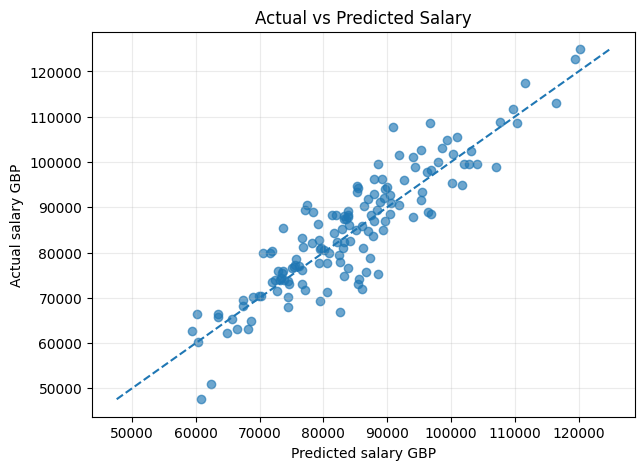

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(predictions['predicted_salary_gbp'], predictions['actual_salary_gbp'], alpha=0.65)
low = min(predictions['predicted_salary_gbp'].min(), predictions['actual_salary_gbp'].min())
high = max(predictions['predicted_salary_gbp'].max(), predictions['actual_salary_gbp'].max())
plt.plot([low, high], [low, high], linestyle='--')
plt.title('Actual vs Predicted Salary')
plt.xlabel('Predicted salary GBP')
plt.ylabel('Actual salary GBP')
plt.grid(alpha=0.25)
plt.show()

## 10. Student exercise
1. Change the test size to 30% and compare metrics.

  R² stays at 0.81 when changed to 30%. So the metrics are very similar.

2. Remove one feature group and observe the error change.

  Removing seniority dropped R² from 0.81 to 0.52. This shows that seniority level is an important predictor in the model.

3. Write one sentence explaining whether the model is useful enough for a low-risk planning estimate.

  With an MAE of £4600 against a mean salary of  ~£78000 (roughly 6% error), the model is accurate enough for broad estimates, but too inaccurate for decisions such as what specific people should be paid.

4. Add one caveat about fairness, representativeness, or deployment.

  If deployed in a real HR system, the model could display unfairness, as historically, males are paid more than females, so there might be gender biases that are already ingrained in the data and might affect salary decisions.

## 11. Homework
Compare linear regression against the baseline predictor and write a short business interpretation using MAE, RMSE, and R2.

Our new salary prediction model delivers highly accurate, dependable insights using just 13 core data points. By replacing our baseline guesswork with statistical precision, this tool provides a robust framework for data-driven compensation planning, talent acquisition, and long-term budget optimization.

At the core of this upgrade is a drastic reduction in forecasting errors. On average, the model's predictions are off by just £4,600 per person. When compared to a simple mean predictor used as a benchmark, this represents a massive £6,244 accuracy improvement per prediction, which significantly tightens our financial forecasting and protects hiring budgets from unnecessary inflation.

Furthermore, the model successfully keeps large, catastrophic errors in check. While the benchmark baseline suffered from a severe RMSE of £13,581, the new model reduces this risk to £5,928. This statistical stabilization ensures that leadership can trust the tool's outputs, confident that it will not produce wildly unrealistic or disruptive budgeting anomalies.

Ultimately, the model captures and explains 81% of all salary variation ($R^2 = 0.81$). Achieving this exceptional level of predictability from a straightforward linear model guarantees that our valuation process remains highly effective, transparent, and legally defensible. Transitioning to this framework protects company margins from costly over-budgeting while ensuring we consistently secure top talent with competitive, equitable offers.